# VAE Baseline

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

from src.utils.paths import load_config, ensure_dir

In [2]:
config = load_config(PROJECT_ROOT / "config.yaml")

figures_dir = ensure_dir(PROJECT_ROOT / config["reports"]["figures_dir"])

vae_log_path = PROJECT_ROOT / "runs" / "vae" / "training_log.csv"
vae_samples_path = PROJECT_ROOT / "reports" / "figures" / "vae_samples_grid.png"
vae_recon_dir = PROJECT_ROOT / "outputs" / "reconstructions" / "vae"
vae_generated_dir = PROJECT_ROOT / "outputs" / "generated_samples" / "vae"

print("VAE log path:", vae_log_path)
print("VAE samples path:", vae_samples_path)
print("VAE reconstruction folder:", vae_recon_dir)

VAE log path: e:\celeba-generative-comparison\runs\vae\training_log.csv
VAE samples path: e:\celeba-generative-comparison\reports\figures\vae_samples_grid.png
VAE reconstruction folder: e:\celeba-generative-comparison\outputs\reconstructions\vae


In [3]:
vae_log = pd.read_csv(vae_log_path)

print("Training log shape:", vae_log.shape)
display(vae_log)

Training log shape: (30, 7)


,epoch,train_total_loss,train_recon_loss,train_kl_loss,val_total_loss,val_recon_loss,val_kl_loss
0,1,979.750313,836.005790,143.744524,631.785000,477.634008,154.150993
1,2,598.738086,444.542811,154.195275,569.597049,414.111669,155.485380
2,3,557.001708,401.800707,155.201000,541.490401,386.213485,155.276917
3,4,534.113708,378.425373,155.688334,517.152485,363.114125,154.038360
4,5,518.698402,363.502125,155.196276,510.942358,356.942279,154.000079
5,6,508.876151,354.732380,154.143772,499.985615,346.746853,153.238762
6,7,502.322886,349.114695,153.208191,505.432452,353.209905,152.222547
7,8,497.023263,344.608398,152.414864,493.490464,341.174508,152.315956
8,9,492.304078,340.526770,151.777308,488.502099,338.279951,150.222149
9,10,488.767185,337.535859,151.231326,484.369647,333.711802,150.657846


In [4]:
summary_cols = [
    "train_total_loss",
    "train_recon_loss",
    "train_kl_loss",
    "val_total_loss",
    "val_recon_loss",
    "val_kl_loss"
]

display(vae_log[summary_cols].describe())

,train_total_loss,train_recon_loss,train_kl_loss,val_total_loss,val_recon_loss,val_kl_loss
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,502.896040,352.606014,150.290026,488.172298,338.318064,149.854234
std,95.266004,95.798895,2.664934,36.848746,34.717293,2.725483
min,460.996294,312.784998,143.744524,461.455938,313.637891,146.376502
25%,466.631910,317.971254,148.588201,466.826503,319.934023,147.808920
50%,475.819920,326.227005,149.433684,474.294435,324.876220,149.250100
75%,495.843467,343.587991,151.640812,492.243372,340.613666,151.831372
max,979.750313,836.005790,155.688334,631.785000,477.634008,155.485380


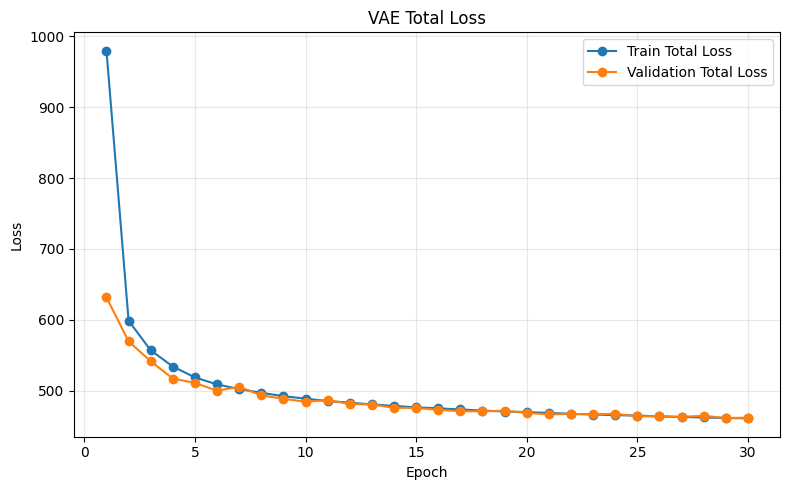

Saved to: e:\celeba-generative-comparison\reports\figures\vae_total_loss_curve.png


In [5]:
plt.figure(figsize=(8, 5))

plt.plot(vae_log["epoch"], vae_log["train_total_loss"], marker="o", label="Train Total Loss")
plt.plot(vae_log["epoch"], vae_log["val_total_loss"], marker="o", label="Validation Total Loss")

plt.title("VAE Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

total_loss_path = figures_dir / "vae_total_loss_curve.png"
plt.savefig(total_loss_path, dpi=150)
plt.show()

print("Saved to:", total_loss_path)

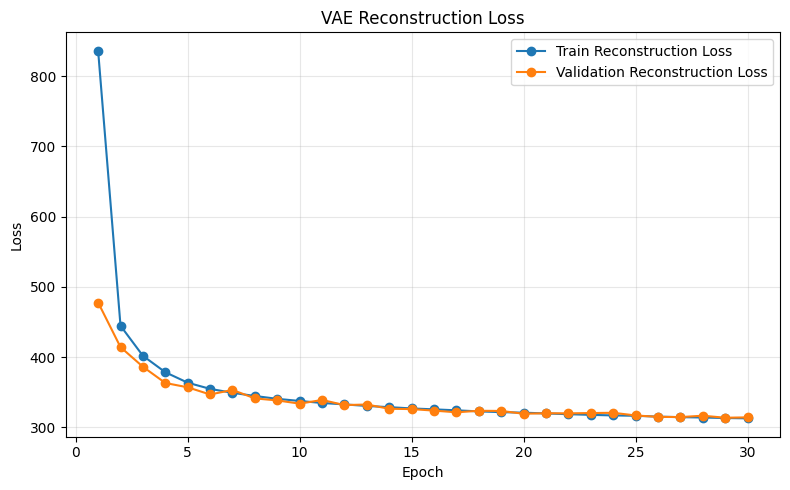

Saved to: e:\celeba-generative-comparison\reports\figures\vae_reconstruction_loss_curve.png


In [6]:
plt.figure(figsize=(8, 5))

plt.plot(vae_log["epoch"], vae_log["train_recon_loss"], marker="o", label="Train Reconstruction Loss")
plt.plot(vae_log["epoch"], vae_log["val_recon_loss"], marker="o", label="Validation Reconstruction Loss")

plt.title("VAE Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

recon_loss_path = figures_dir / "vae_reconstruction_loss_curve.png"
plt.savefig(recon_loss_path, dpi=150)
plt.show()

print("Saved to:", recon_loss_path)

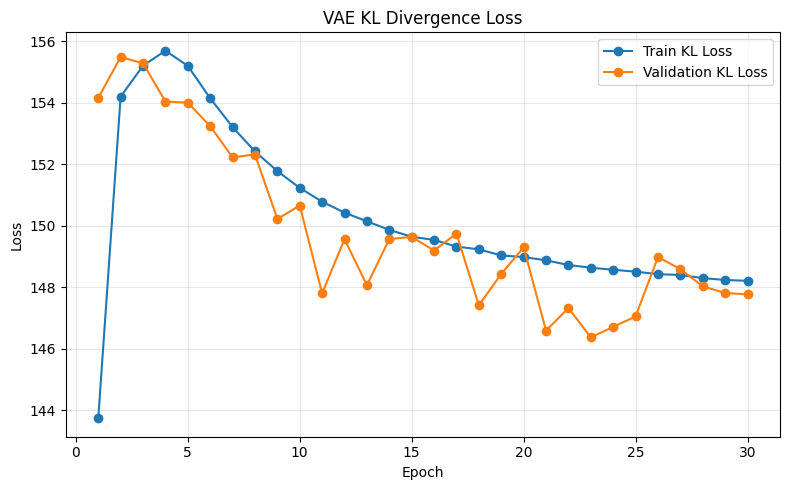

Saved to: e:\celeba-generative-comparison\reports\figures\vae_kl_loss_curve.png


In [7]:
plt.figure(figsize=(8, 5))

plt.plot(vae_log["epoch"], vae_log["train_kl_loss"], marker="o", label="Train KL Loss")
plt.plot(vae_log["epoch"], vae_log["val_kl_loss"], marker="o", label="Validation KL Loss")

plt.title("VAE KL Divergence Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

kl_loss_path = figures_dir / "vae_kl_loss_curve.png"
plt.savefig(kl_loss_path, dpi=150)
plt.show()

print("Saved to:", kl_loss_path)

## VAE Training Behaviour

The VAE training loss decreased steadily across training, showing that the model successfully learned to reconstruct CelebA face images.

Most of the improvement came from the reconstruction loss, while the KL-divergence term stayed relatively stable. This suggests that the model learned a useful latent representation without the latent regularisation term becoming unstable.

The validation loss also decreased, which suggests that the model was learning general face structure rather than simply memorising the training set.

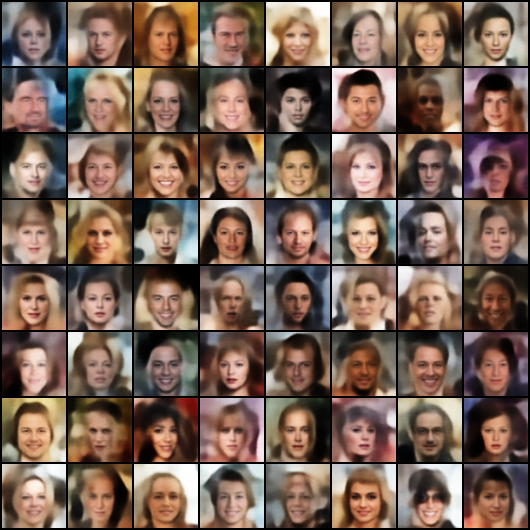

In [8]:
if vae_samples_path.exists():
    img = Image.open(vae_samples_path)
    display(img)
else:
    print("VAE sample grid not found:", vae_samples_path)

## VAE Generated Samples

The VAE generated samples show that the model has learned the general structure of CelebA face images. Many samples contain recognisable face layouts, including approximate hair regions, skin-tone areas, and rough eye, nose, and mouth placement.

However, the images are noticeably blurry and lack fine facial details. This is expected for a basic VAE because the model optimises a reconstruction-based objective with latent-space regularisation. The VAE is therefore useful as a stable baseline, but it is not expected to produce the sharpest or most realistic outputs.

Displaying: e:\celeba-generative-comparison\outputs\reconstructions\vae\epoch_030_reconstructions.png


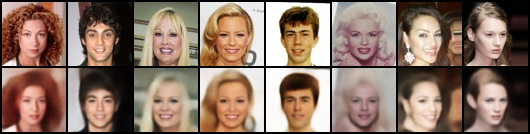

In [9]:
recon_files = sorted(vae_recon_dir.glob("*reconstructions.png"))

if len(recon_files) > 0:
    latest_recon = recon_files[-1]
    print("Displaying:", latest_recon)
    display(Image.open(latest_recon))
else:
    print("No reconstruction files found in:", vae_recon_dir)

## VAE Reconstruction Quality

The reconstruction grid compares original images with their reconstructed versions. The reconstructions preserve the general face layout, colours, and broad visual structure, but fine details are smoothed out.

This confirms the expected behaviour of a VAE: it learns a compressed latent representation that captures major visual patterns, but it loses some high-frequency details during reconstruction.

Displaying: e:\celeba-generative-comparison\outputs\generated_samples\vae\epoch_030_generated.png


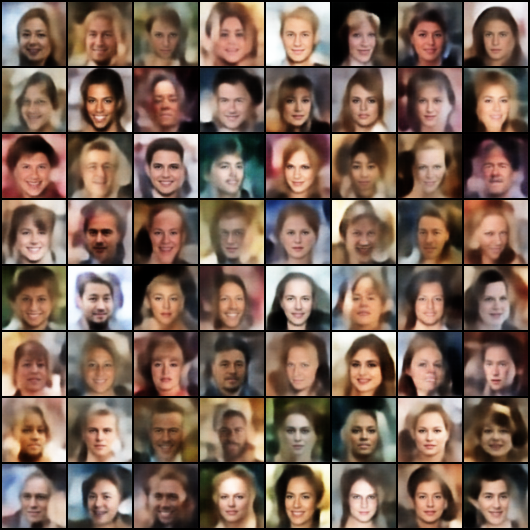

In [10]:
generated_files = sorted(vae_generated_dir.glob("*generated.png"))

if len(generated_files) > 0:
    latest_generated = generated_files[-1]
    print("Displaying:", latest_generated)
    display(Image.open(latest_generated))
else:
    print("No generated files found in:", vae_generated_dir)

## VAE Baseline Summary

The VAE baseline successfully learned the broad distribution of CelebA face images. The generated samples are face-like and show basic facial structure, but they are smooth and blurry.

This result is suitable as the first baseline model. It provides a useful comparison point for the next models:

- DCGAN should produce sharper images but may be less stable during training
- Diffusion should produce more stable and diverse samples, but with slower sampling

Overall, the VAE confirms that the dataset pipeline and generative training workflow are working correctly.